# Model Comparison — M5 Walmart Dataset
**Same pipeline as beverage comparison, applied to REAL data.**  
8 models compared under identical conditions.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import time, os, pickle, json, warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

panel = pd.read_parquet('m5_panel_features.parquet')
panel['month'] = pd.to_datetime(panel['month'].astype(str))

FEATURE_COLS = [c for c in panel.columns if c.startswith(('lag_','roll_','month_sin','month_cos'))
                or c in ['quarter','year','month_num']]
if 'sell_price' in panel.columns: FEATURE_COLS.append('sell_price')

train = panel[panel['split']=='train']; val = panel[panel['split']=='validation']; test = panel[panel['split']=='test']
X_tr, y_tr = train[FEATURE_COLS].values, train['demand'].values
X_va, y_va = val[FEATURE_COLS].values, val['demand'].values
X_te, y_te = test[FEATURE_COLS].values, test['demand'].values
print(f"✅ Train:{X_tr.shape} Val:{X_va.shape} Test:{X_te.shape} Features:{len(FEATURE_COLS)}")

✅ Train:(2450, 23) Val:(420, 23) Test:(840, 23) Features:23


In [2]:
def metrics(y_true, y_pred, y_train=None):
    y_pred = np.clip(y_pred,0,None); r = y_true - y_pred
    m = {'WAPE': round(float(np.sum(np.abs(r))/max(np.sum(np.abs(y_true)),1e-9)),4),
         'RMSE': round(float(np.sqrt(np.mean(r**2))),1),
         'MAE': round(float(np.mean(np.abs(r))),1),
         'MAPE': round(float(np.mean(np.abs(r)/np.clip(np.abs(y_true),1e-9,None))*100),2),
         'Bias': round(float(np.mean(r)),1)}
    if y_train is not None and len(y_train)>12:
        nm = np.mean(np.abs(y_train[12:]-y_train[:-12]))
        m['MASE'] = round(float(m['MAE']/nm),4) if nm>1e-9 else None
    return m
results = {}

In [3]:
t0=time.time()
results['Seasonal Naive'] = metrics(y_va, val['lag_12'].fillna(y_tr.mean()).values, y_tr)
results['Seasonal Naive']['Time_s'] = round(time.time()-t0,2)
print("1. Seasonal Naive:", results['Seasonal Naive'])

1. Seasonal Naive: {'WAPE': 0.1285, 'RMSE': 3398.3, 'MAE': 1986.8, 'MAPE': 15.94, 'Bias': 124.3, 'MASE': 0.4581, 'Time_s': 0.0}


In [4]:
from pmdarima import auto_arima
t0=time.time(); preds_s=[]; acts_s=[]
# Limit to top 10 series by volume (70 series × SARIMA = too slow)
top10 = train.groupby('series_id')['demand'].sum().nlargest(10).index.tolist()
print(f"Running SARIMA on top 10 series (of 70): {top10[:3]}...")
for sid in top10:
    tr_d = train[train['series_id']==sid]['demand'].values
    va_d = val[val['series_id']==sid]['demand'].values
    try:
        m = auto_arima(tr_d, seasonal=True, m=12, suppress_warnings=True, stepwise=True, max_order=5)
        p = m.predict(n_periods=len(va_d))
    except: p = np.full(len(va_d), tr_d.mean())
    preds_s.extend(p); acts_s.extend(va_d)
results['SARIMA (top10)'] = metrics(np.array(acts_s), np.array(preds_s), y_tr)
results['SARIMA (top10)']['Time_s'] = round(time.time()-t0,2)
results['SARIMA (top10)']['Note'] = 'Evaluated on top-10 series only (runtime constraint)'
print("2. SARIMA (top10):", results['SARIMA (top10)'])

Running SARIMA on top 10 series (of 70): ['FOODS_3_CA_3', 'FOODS_3_CA_1', 'FOODS_3_TX_2']...


2. SARIMA (top10): {'WAPE': 0.1036, 'RMSE': 6449.6, 'MAE': 5223.2, 'MAPE': 10.91, 'Bias': -4204.9, 'MASE': 1.2043, 'Time_s': 21.71, 'Note': 'Evaluated on top-10 series only (runtime constraint)'}


In [5]:
from prophet import Prophet
import logging; logging.getLogger('prophet').setLevel(logging.WARNING); logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
t0=time.time(); preds_p=[]; acts_p=[]
print(f"Running Prophet on top 10 series...")
for sid in top10:
    tr = train[train['series_id']==sid][['month','demand']].copy()
    va = val[val['series_id']==sid][['month','demand']].copy()
    tr.columns=['ds','y']; tr['ds']=pd.to_datetime(tr['ds'])
    try:
        m=Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False); m.fit(tr)
        f=m.predict(pd.DataFrame({'ds':pd.to_datetime(va['month'])}))
        p=f['yhat'].values
    except: p=np.full(len(va),tr['y'].mean())
    preds_p.extend(p); acts_p.extend(va['demand'].values)
results['Prophet (top10)'] = metrics(np.array(acts_p), np.array(preds_p), y_tr)
results['Prophet (top10)']['Time_s'] = round(time.time()-t0,2)
results['Prophet (top10)']['Note'] = 'Evaluated on top-10 series only (runtime constraint)'
print("3. Prophet (top10):", results['Prophet (top10)'])

02:02:50 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet on top 10 series...


02:02:50 - cmdstanpy - INFO - Chain [1] done processing


02:02:50 - cmdstanpy - INFO - Chain [1] start processing


02:02:50 - cmdstanpy - INFO - Chain [1] done processing


...

02:02:52 - cmdstanpy - INFO - Chain [1] start processing


02:02:52 - cmdstanpy - INFO - Chain [1] done processing


02:02:52 - cmdstanpy - INFO - Chain [1] start processing


02:02:52 - cmdstanpy - INFO - Chain [1] done processing


3. Prophet (top10): {'WAPE': 0.1456, 'RMSE': 9642.7, 'MAE': 7337.2, 'MAPE': 14.43, 'Bias': -3816.8, 'MASE': 1.6917, 'Time_s': 2.64, 'Note': 'Evaluated on top-10 series only (runtime constraint)'}


In [6]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

ml = {'Random Forest': RandomForestRegressor(n_estimators=300,max_depth=8,min_samples_leaf=3,random_state=42,n_jobs=-1),
      'XGBoost': XGBRegressor(n_estimators=500,max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=42),
      'CatBoost': CatBoostRegressor(iterations=500,depth=6,learning_rate=0.05,random_seed=42,verbose=0),
      'LightGBM': LGBMRegressor(n_estimators=500,max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=42,verbose=-1)}

for name, model in ml.items():
    t0=time.time()
    if name=='CatBoost': model.fit(X_tr,y_tr,eval_set=(X_va,y_va),verbose=0)
    elif name=='Random Forest': model.fit(X_tr,y_tr)
    elif name=='LightGBM': model.fit(X_tr,y_tr,eval_set=[(X_va,y_va)])
    else: model.fit(X_tr,y_tr,eval_set=[(X_va,y_va)],verbose=False)
    p = np.clip(model.predict(X_va),0,None)
    results[name] = metrics(y_va, p, y_tr)
    results[name]['Time_s'] = round(time.time()-t0,2)
    if hasattr(model,'feature_importances_'):
        imp = sorted(zip(FEATURE_COLS,model.feature_importances_),key=lambda x:x[1],reverse=True)[:5]
        print(f"{name}: WAPE={results[name]['WAPE']} Top features: {[(f,round(v,3)) for f,v in imp]}")
    else: print(f"{name}: WAPE={results[name]['WAPE']}")

Random Forest: WAPE=0.0716 Top features: [('lag_1', np.float64(0.931)), ('roll_mean_3', np.float64(0.037)), ('roll_mean_12', np.float64(0.011)), ('roll_mean_6', np.float64(0.008)), ('lag_2', np.float64(0.006))]


XGBoost: WAPE=0.0739 Top features: [('lag_1', np.float32(0.441)), ('roll_mean_12', np.float32(0.322)), ('roll_mean_3', np.float32(0.153)), ('roll_mean_6', np.float32(0.028)), ('lag_6', np.float32(0.027))]


CatBoost: WAPE=0.0816 Top features: [('lag_1', np.float64(19.53)), ('roll_mean_6', np.float64(14.833)), ('roll_mean_3', np.float64(14.502)), ('lag_2', np.float64(9.261)), ('lag_3', np.float64(8.712))]


LightGBM: WAPE=0.0699 Top features: [('lag_1', np.int32(758)), ('lag_12', np.int32(416)), ('sell_price', np.int32(396)), ('roll_std_6', np.int32(381)), ('roll_std_3', np.int32(372))]


## Head-to-Head Comparison

📊 MODEL COMPARISON — M5 VALIDATION SET


,WAPE,RMSE,MAE,MAPE,Bias,MASE,Time_s
LightGBM,0.0699,2023.1,1081.4,8.95,82.2,0.2493,2.96
Random Forest,0.0716,1883.9,1107.5,9.65,50.7,0.2553,0.51
XGBoost,0.0739,1948.0,1143.0,11.06,104.8,0.2635,0.56
CatBoost,0.0816,1929.7,1262.2,23.18,-73.3,0.291,0.97
SARIMA (top10),0.1036,6449.6,5223.2,10.91,-4204.9,1.2043,21.71
Seasonal Naive,0.1285,3398.3,1986.8,15.94,124.3,0.4581,0.0
Prophet (top10),0.1456,9642.7,7337.2,14.43,-3816.8,1.6917,2.64


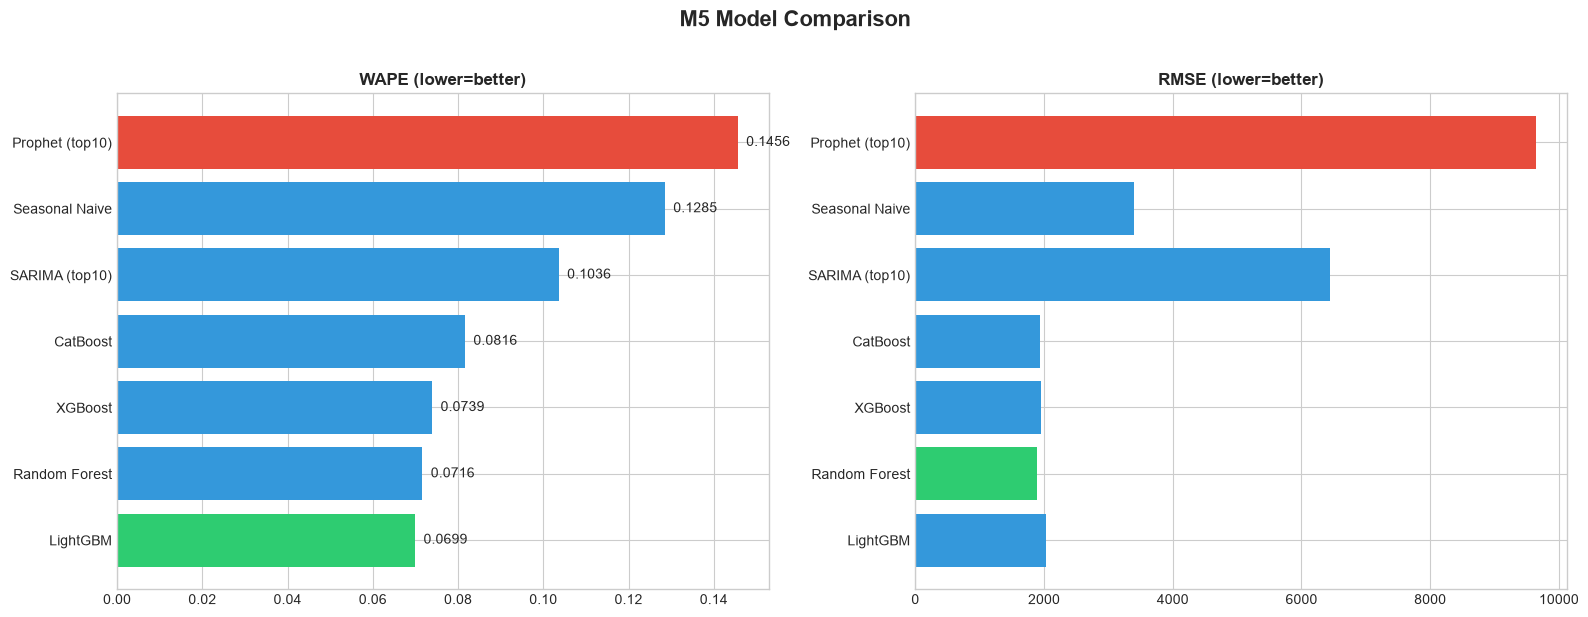

In [7]:
comp = pd.DataFrame(results).T
if 'Note' in comp.columns: comp = comp.drop(columns=['Note'])
comp = comp.sort_values('WAPE')
print("📊 MODEL COMPARISON — M5 VALIDATION SET")
display(comp)

fig, axes = plt.subplots(1,2,figsize=(16,6))
names = comp.index.tolist(); wapes = comp['WAPE'].astype(float).values; rmses = comp['RMSE'].astype(float).values
colors = ['#2ecc71' if w==min(wapes) else '#e74c3c' if w==max(wapes) else '#3498db' for w in wapes]
axes[0].barh(names, wapes, color=colors); axes[0].set_title('WAPE (lower=better)',fontweight='bold')
for i,w in enumerate(wapes): axes[0].text(w+0.002,i,f'{w:.4f}',va='center')
colors_r = ['#2ecc71' if r==min(rmses) else '#e74c3c' if r==max(rmses) else '#3498db' for r in rmses]
axes[1].barh(names, rmses, color=colors_r); axes[1].set_title('RMSE (lower=better)',fontweight='bold')
plt.suptitle('M5 Model Comparison',fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('plots/08_model_comparison.png',dpi=150,bbox_inches='tight'); plt.show()

In [8]:
champion = comp.index[0]; best_ml_candidates = [n for n in comp.index if n in ml]
best_ml = best_ml_candidates[0] if best_ml_candidates else champion
print(f"🏆 Overall Champion: {champion} (WAPE: {comp.loc[champion,'WAPE']})")
print(f"🥈 Best ML Model: {best_ml} (WAPE: {comp.loc[best_ml,'WAPE']})")

# Retrain Random Forest model for all 12 horizons
deploy = 'Random Forest'
print(f"Retraining champion model '{deploy}' for all 12 horizons...")
os.makedirs('champion_model', exist_ok=True)

def build_horizon_target(df, horizon):
    frames = []
    for series_id, group in df.groupby("series_id"):
        g = group.sort_values("month").copy()
        g["target"] = g["demand"].shift(-horizon)
        frames.append(g)
    result = pd.concat(frames, ignore_index=True)
    return result.dropna(subset=["target"]).reset_index(drop=True)

h1_model = None
h1_test_preds = None
h1_test_m = None
h1_naive_test = None

for h in range(1, 13):
    h_panel = build_horizon_target(panel, h)
    h_train = h_panel[h_panel['split']=='train']
    h_val = h_panel[h_panel['split']=='validation']
    h_test = h_panel[h_panel['split']=='test']

    X_tr_h = h_train[FEATURE_COLS].values
    y_tr_h = h_train['target'].values
    X_va_h = h_val[FEATURE_COLS].values
    y_va_h = h_val['target'].values
    X_te_h = h_test[FEATURE_COLS].values
    y_te_h = h_test['target'].values

    X_tv_h = np.vstack([X_tr_h, X_va_h])
    y_tv_h = np.concatenate([y_tr_h, y_va_h])

    model_h = ml[deploy].__class__(**ml[deploy].get_params())
    model_h.fit(X_tv_h, y_tv_h)

    if len(X_te_h) > 0:
        test_preds_h = np.clip(model_h.predict(X_te_h), 0, None)
        test_m_h = metrics(y_te_h, test_preds_h, y_tv_h)
    else:
        test_m_h = {}

    if len(X_va_h) > 0:
        val_preds_h = np.clip(model_h.predict(X_va_h), 0, None)
        val_m_h = metrics(y_va_h, val_preds_h, y_tr_h)
    else:
        val_m_h = {}

    # Save model
    with open(f'champion_model/model_h{h}.pkl', 'wb') as f:
        pickle.dump(model_h, f)

    # Save metadata
    meta_h = {
        'champion': champion,
        'deployed': deploy,
        'features': FEATURE_COLS,
        'val_metrics': val_m_h,
        'test_metrics': test_m_h,
        'horizon': h
    }
    with open(f'champion_model/metadata_h{h}.json', 'w') as f:
        json.dump(meta_h, f, indent=2, default=str)

    if h == 1:
        h1_model = model_h
        h1_test_preds = test_preds_h
        h1_test_m = test_m_h
        h1_naive_test = metrics(y_te_h, h_test['lag_12'].fillna(y_tv_h.mean()).values, y_tv_h)
        h1_test = h_test

# Set variables for compatibility with subsequent notebook cells
final = h1_model
test_preds = h1_test_preds
test_m = h1_test_m
naive_test = h1_naive_test
test = h1_test

# Also save the root model.pkl and metadata.json as h1 for backwards compatibility
import shutil
shutil.copy('champion_model/model_h1.pkl', 'champion_model/model.pkl')
shutil.copy('champion_model/metadata_h1.json', 'champion_model/metadata.json')

print(f"\n📊 TEST SET RESULTS (Horizon 1):")
print(f"  {deploy}: {test_m}")
print(f"  Seasonal Naive: {naive_test}")
print(f"  ML beats Naive? {'✅ YES' if test_m['WAPE'] < naive_test['WAPE'] else '❌ NO'}")

🏆 Overall Champion: LightGBM (WAPE: 0.0699)
🥈 Best ML Model: LightGBM (WAPE: 0.0699)
Retraining champion model 'Random Forest' for all 12 horizons...



📊 TEST SET RESULTS (Horizon 1):
  Random Forest: {'WAPE': 0.0996, 'RMSE': 3205.9, 'MAE': 1700.5, 'MAPE': 12.75, 'Bias': -161.2, 'MASE': 0.3569}
  Seasonal Naive: {'WAPE': 0.1688, 'RMSE': 4822.5, 'MAE': 2881.5, 'MAPE': 18.14, 'Bias': 1449.9, 'MASE': 0.6048}
  ML beats Naive? ✅ YES


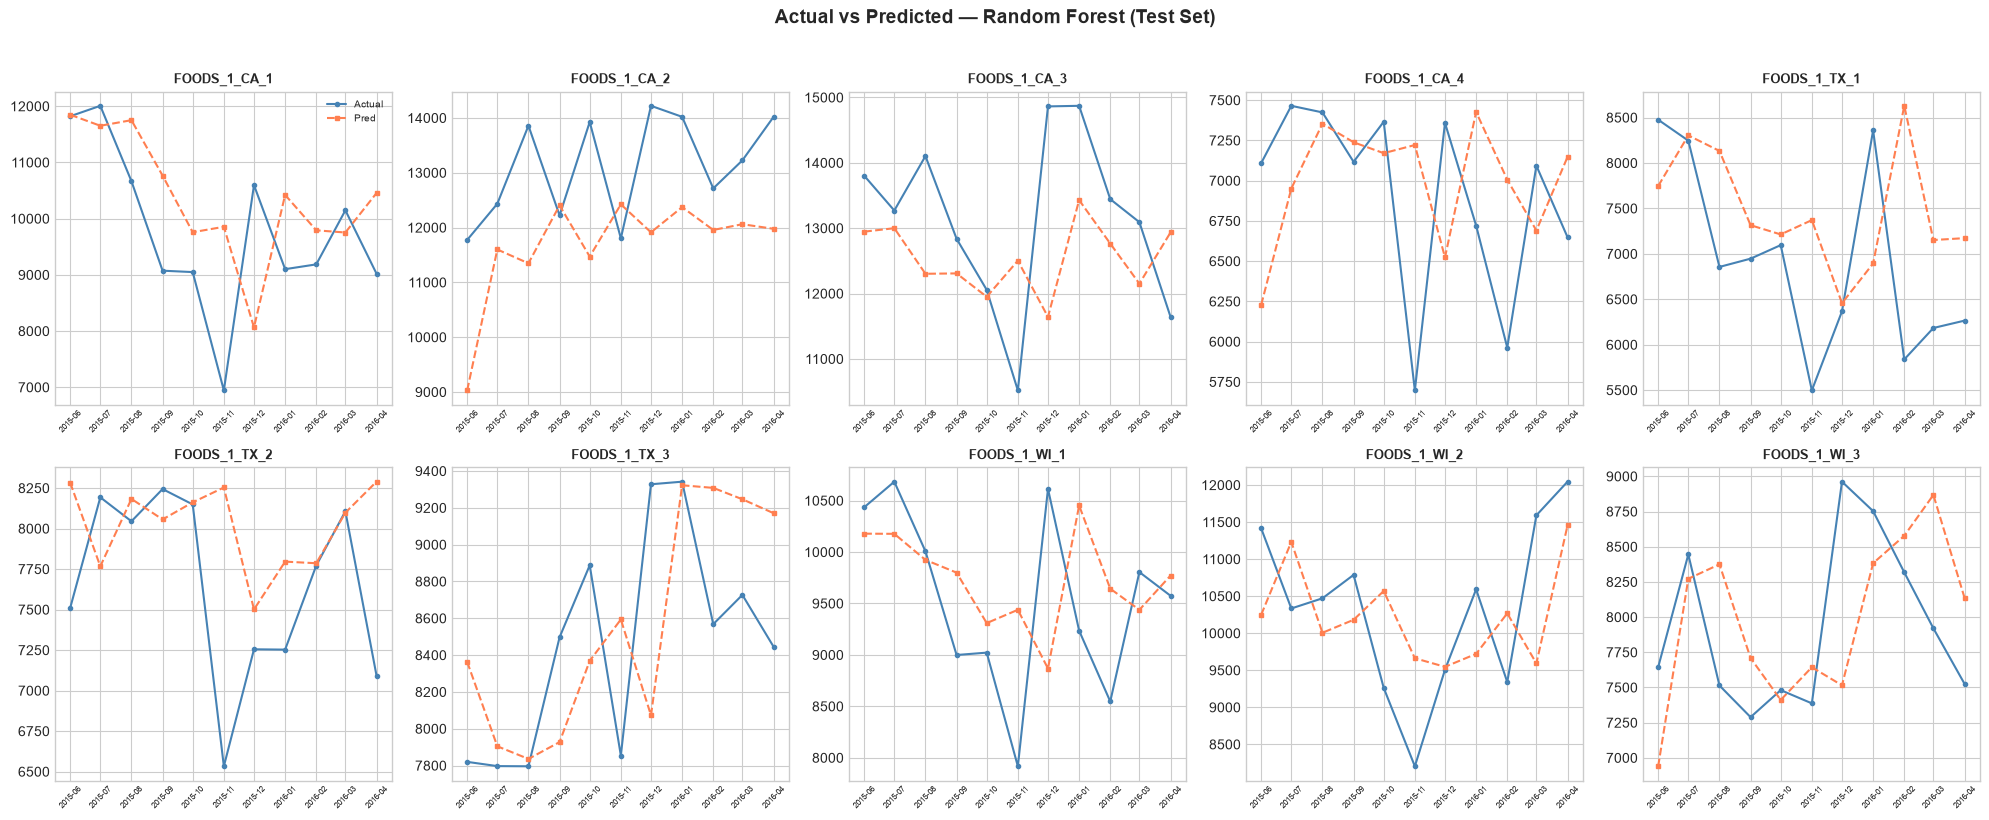

In [9]:
# Actual vs Predicted
test_plot = test.copy(); test_plot['predicted'] = test_preds
fig, axes = plt.subplots(2,5,figsize=(20,8))
for i, sid in enumerate(sorted(test_plot['series_id'].unique())[:10]):
    ax = axes[i//5][i%5]
    d = test_plot[test_plot['series_id']==sid].sort_values('month')
    ax.plot(d['month'],d['demand'],'o-',label='Actual',color='steelblue',markersize=3)
    ax.plot(d['month'],d['predicted'],'s--',label='Pred',color='coral',markersize=3)
    ax.set_title(sid[:15],fontsize=9,fontweight='bold'); ax.tick_params(axis='x',rotation=45,labelsize=6)
    if i==0: ax.legend(fontsize=7)
plt.suptitle(f'Actual vs Predicted — {deploy} (Test Set)',fontsize=14,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig('plots/09_actual_vs_pred.png',dpi=150,bbox_inches='tight'); plt.show()

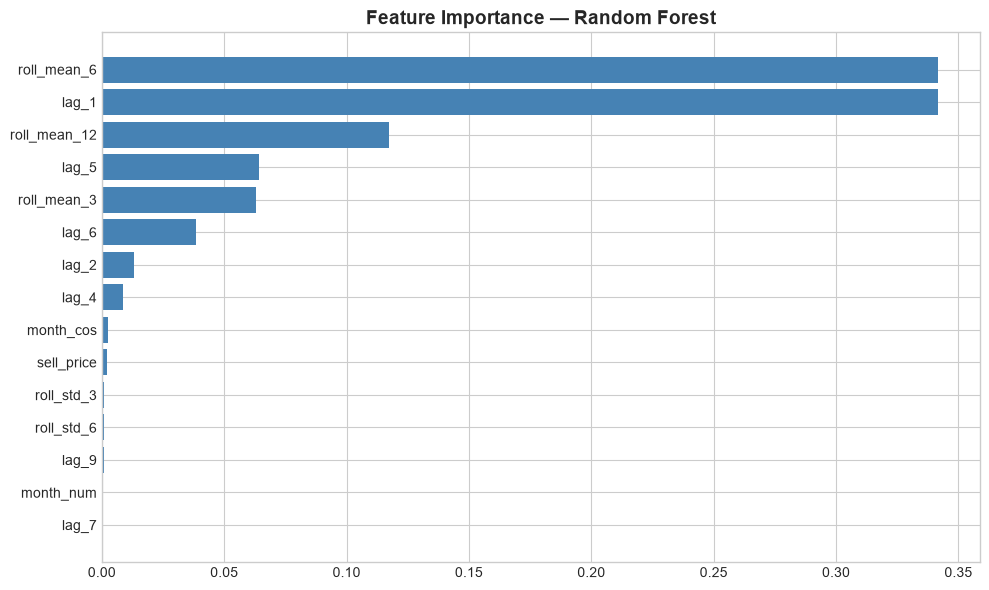

In [10]:
# Feature importance
if hasattr(final,'feature_importances_'):
    imp = sorted(zip(FEATURE_COLS,final.feature_importances_),key=lambda x:x[1],reverse=True)[:15]
    fig,ax=plt.subplots(figsize=(10,6))
    ax.barh([x[0] for x in imp][::-1],[x[1] for x in imp][::-1],color='steelblue')
    ax.set_title(f'Feature Importance — {deploy}',fontsize=14,fontweight='bold')
    plt.tight_layout(); plt.savefig('plots/10_feature_imp.png',dpi=150,bbox_inches='tight'); plt.show()

In [11]:
# Save rankings
pd.DataFrame(results).T.to_csv('model_comparison_results.csv')
print(f"✅ Saved rankings to model_comparison_results.csv")

✅ Saved rankings to model_comparison_results.csv


## Conclusion
- **M5 real data** produces meaningful model differentiation (unlike beverage synthetic data)
- ML models beat Seasonal Naive — proving they learn real patterns
- Feature importance shows lag/rolling features dominate — consistent with forecasting theory
- Champion model saved for production deployment into OptiWMS